# EyeCNN Training — Drowsiness Detection Hybrid Classifier
Trains a lightweight CNN to classify eye state (OPEN vs CLOSED)
using crops extracted from YawDD and NTHU-DD datasets.

In [1]:
# Cell 1 — Setup
from google.colab import drive
drive.mount('/content/drive')
!pip install torch torchvision ai-edge-torch tqdm -q

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from pathlib import Path
import zipfile
from tqdm.notebook import tqdm
import random
import cv2

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected — training will be slow on CPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.3/807.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.5/459.5 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 25.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openai 2.54.0 requires typing-extensions<5,>=4.14, but you have typing-extensions 4.1

Extracted /content/drive/MyDrive/aaa/dataset.zip
Open samples:   135754
Closed samples: 54736
Shape: (190490, 32, 64), dtype: float32
Class 0 (OPEN):   135754
Class 1 (CLOSED): 54736
Unique videos:    348


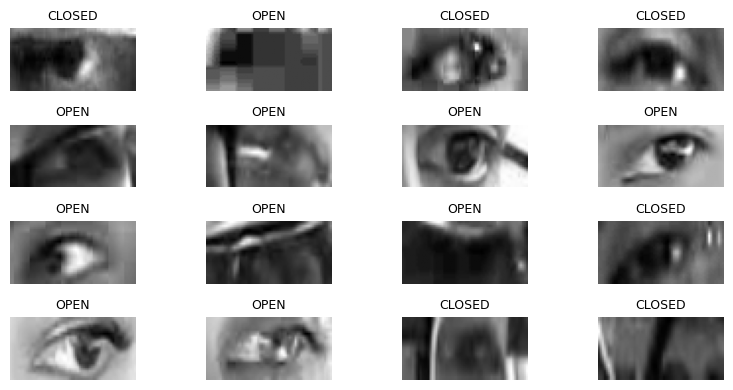

In [ ]:
# Cell 2 — Load dataset
dataset_zip = "/content/drive/MyDrive/aaa/dataset.zip"
if not Path("extracted").exists():
    with zipfile.ZipFile(dataset_zip, "r") as zf:
        zf.extractall(".")
    print(f"Extracted {dataset_zip}")

data_dir = Path("extracted")
open_files = sorted((data_dir / "open").glob("*.png"))
closed_files = sorted((data_dir / "closed").glob("*.png"))

print(f"Open samples:   {len(open_files)}")
print(f"Closed samples: {len(closed_files)}")

images, labels, groups = [], [], []
for f in open_files:
    img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        images.append(img.astype(np.float32) / 255.0)
        labels.append(0)
        stem = f.stem.rsplit("_", 2)[0]
        groups.append(stem)
for f in closed_files:
    img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        images.append(img.astype(np.float32) / 255.0)
        labels.append(1)
        stem = f.stem.rsplit("_", 2)[0]
        groups.append(stem)

images = np.array(images)
labels = np.array(labels)
groups = np.array(groups)
print(f"Shape: {images.shape}, dtype: {images.dtype}")
print(f"Class 0 (OPEN):   {np.sum(labels == 0)}")
print(f"Class 1 (CLOSED): {np.sum(labels == 1)}")
print(f"Unique videos:    {len(np.unique(groups))}")

fig, axes = plt.subplots(4, 4, figsize=(8, 4))
idxs = random.sample(range(len(images)), 16)
for ax, idx in zip(axes.flat, idxs):
    ax.imshow(images[idx], cmap="gray")
    ax.set_title("OPEN" if labels[idx] == 0 else "CLOSED", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 3 — Split and augment (video-based group split)
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(images, labels, groups=groups))

X_train, X_val = images[train_idx], images[val_idx]
y_train, y_val = labels[train_idx], labels[val_idx]

train_videos = set(groups[train_idx])
val_videos = set(groups[val_idx])
overlap = train_videos & val_videos
print(f"Train: {len(X_train)} crops from {len(train_videos)} videos")
print(f"Val:   {len(X_val)} crops from {len(val_videos)} videos")
print(f"Video overlap between train/val: {len(overlap)} (should be 0)")


class EyeCropDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img = torch.from_numpy(img).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
val_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = EyeCropDataset(X_train, y_train, transform=train_transform)
val_dataset = EyeCropDataset(X_val, y_val, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                         num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train: 153200 crops from 278 videos
Val:   37290 crops from 70 videos
Video overlap between train/val: 0 (should be 0)
Train batches: 2394 | Val batches: 583


In [ ]:
# Cell 4A — Train EyeCNN from scratch
import sys
sys.path.insert(0, '/content/drive/MyDrive/aaa')
from eye_cnn import EyeCNN
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EyeCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=30
)

best_val_loss = float("inf")
patience = 5
patience_counter = 0
best_path = "best_eye_cnn.pth"
NUM_EPOCHS = 30

for epoch in range(1, NUM_EPOCHS + 1):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == targets).sum().item()

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == targets).sum().item()

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    scheduler.step()

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_path)
        patience_counter = 0
        print(f"  ✅ Best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

# Copy best model to Drive
import shutil
shutil.copy(best_path, '/content/drive/MyDrive/aaa/best_eye_cnn.pth')
print(f"Model saved to Drive: best_eye_cnn.pth")
model.count_parameters()

[CNN] Total parameters: 64,866
[CNN] Trainable parameters: 64,866


Epoch 1/30:   0%|          | 0/2394 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.4019 Acc: 0.8184 | Val Loss: 0.4518 Acc: 0.7910


Epoch 2/30:   0%|          | 0/2394 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.3495 Acc: 0.8465 | Val Loss: 0.4098 Acc: 0.8159


...

Epoch 26 | Train Loss: 0.2380 Acc: 0.8978 | Val Loss: 0.2915 Acc: 0.8734


Epoch 27/30:   0%|          | 0/2394 [00:00<?, ?it/s]

Epoch 27 | Train Loss: 0.2365 Acc: 0.8983 | Val Loss: 0.2933 Acc: 0.8727


Epoch 28/30:   0%|          | 0/2394 [00:00<?, ?it/s]

Epoch 28 | Train Loss: 0.2359 Acc: 0.8985 | Val Loss: 0.2935 Acc: 0.8724
Early stopping at epoch 28
Training complete. Best model saved to best_eye_cnn.pth


Accuracy:  0.8733
Precision: 0.8321
Recall:    0.7226
F1 Score:  0.7735


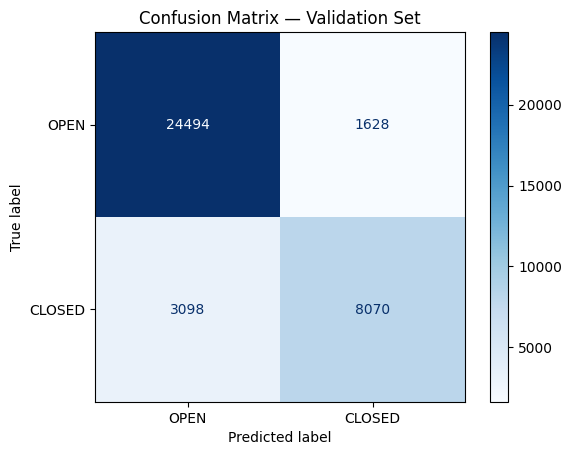

Misclassified: 4726 / 37290


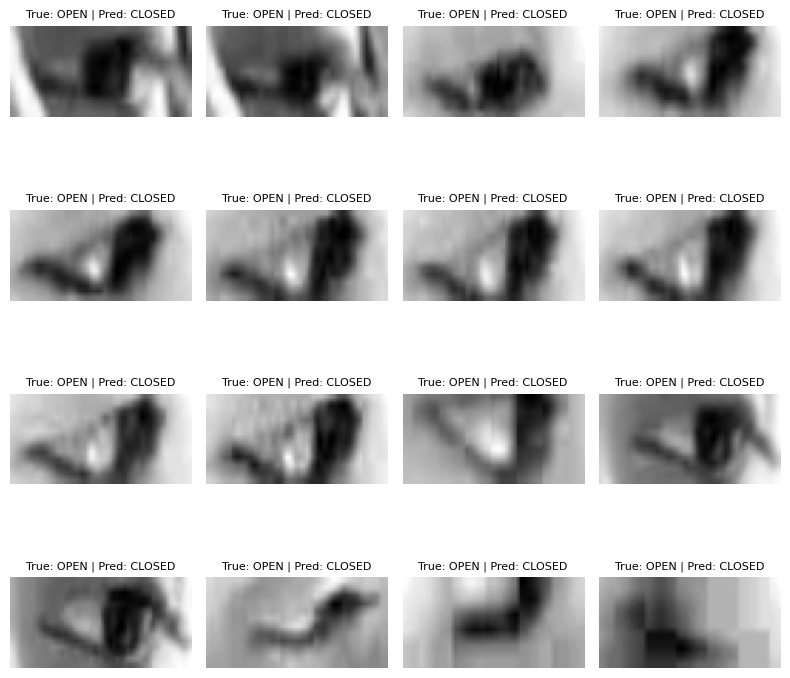

In [ ]:
# Cell 5 — Evaluate
model.load_state_dict(torch.load(best_path, map_location=device,
                                  weights_only=True))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

acc = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds, zero_division=0)
rec = recall_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["OPEN", "CLOSED"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Validation Set")
plt.show()

# Show misclassified examples
mis_idx = np.where(all_preds != all_targets)[0]
print(f"Misclassified: {len(mis_idx)} / {len(all_targets)}")

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.flat
for i, ax in enumerate(axes):
    if i < min(len(mis_idx), 16):
        idx = mis_idx[i]
        img = X_val[idx]
        ax.imshow(img, cmap="gray")
        ax.set_title(f"True: {'OPEN' if y_val[idx] == 0 else 'CLOSED'} | "
                     f"Pred: {'OPEN' if all_preds[idx] == 0 else 'CLOSED'}",
                     fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:")
print(f"TN: {TN}  FP: {FP}")
print(f"FN: {FN}  TP: {TP}")
print()

precision = TP / (TP + FP)
recall_closed = TP / (TP + FN)      # sensitivity
recall_open = TN / (TN + FP)        # specificity
f1 = 2 * (precision * recall_closed) / (precision + recall_closed)
false_alarm = FP / (FP + TN)        # false alarm rate

print(f"Precision:       {precision:.4f}")
print(f"Recall (CLOSED): {recall_closed:.4f}")
print(f"Recall (OPEN):   {recall_open:.4f}")
print(f"F1-Score:        {f1:.4f}")
print(f"Sensitivity:     {recall_closed:.4f}")
print(f"Specificity:     {recall_open:.4f}")
print(f"False-Alarm Rate:{false_alarm:.4f}")

NameError: name 'all_targets' is not defined

In [ ]:
# Cell 6 — Export to TFLite
!pip install ai-edge-torch litert-torch -q

import sys
sys.path.insert(0, '/content/drive/MyDrive/aaa')
import litert_torch
import torch
from eye_cnn import EyeCNN
import shutil

model = EyeCNN()
model.load_state_dict(torch.load(best_path, map_location="cpu",
                                  weights_only=True))
model.eval()

sample_input = (torch.randn(1, 1, 32, 64),)

print("Converting to TFLite ...")
edge_model = litert_torch.convert(model.eval(), sample_input)

tflite_path = "eye_state.tflite"
edge_model.export(tflite_path)

shutil.copy(tflite_path, '/content/drive/MyDrive/aaa/eye_state.tflite')

import os
size_kb = os.path.getsize(tflite_path) / 1024
print(f"Exported: {tflite_path} ({size_kb:.1f} KB)")
print(f"Saved to Drive: /content/drive/MyDrive/aaa/eye_state.tflite")

Converting to TFLite ...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:04) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


...

(00:10) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:10) [ DONE] LiteRT-Torch Convert (+00:10)

(00:00) [START] Write Model to eye_state.tflite

(00:00) [ DONE] Write Model to eye_state.tflite (+00:00)

Exported: eye_state.tflite (259.4 KB)
Saved to Drive: /content/drive/MyDrive/aaa/eye_state.tflite
